# 🔐 UEBA Lab — Notebook 01: Data Ingestion & Feature Engineering

**Dataset:** CMU CERT Insider Threat Dataset r4.2 (`certr42.zip`)  
**Environment:** 16GB RAM — email sampled to 10% (≤1M rows), http sampled to 1% (≤1M rows)

| Section | Topic |
|---------|-------|
| 1.0 | Setup & Configuration |
| 1.1 | Extract & Load CSVs (with sampling) |
| 1.2 | LDAP Enrichment |
| 1.3 | EDA |
| 1.4 | Feature Engineering |
| 1.5 | Save Feature Matrix |

## 1.0 Setup & Configuration

In [1]:
# Cell 1 — Install dependencies
!pip install -r requirements.txt -q

In [2]:
# Cell 2 — Imports and global config
import os, sys, zipfile, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
from tqdm import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

ARCHIVE_NAME         = 'certr42.zip'
EXTRACT_DIR          = './cert_r42'
BASELINE_WINDOW_DAYS = 30
RANDOM_SEED          = 42

EMAIL_SAMPLE_FRAC = 0.10
EMAIL_SAMPLE_CAP  = 1_000_000
HTTP_SAMPLE_FRAC  = 0.01
HTTP_SAMPLE_CAP   = 1_000_000

SENSITIVE_KEYWORDS    = ['model','proprietary','confidential','secret','patent',
                          'source','algorithm','key','credential','private',
                          'internal','classified','restricted']
JOB_SITE_DOMAINS      = ['linkedin.com','indeed.com','glassdoor.com',
                          'monster.com','careerbuilder.com','ziprecruiter.com']
CLOUD_STORAGE_DOMAINS = ['dropbox.com','drive.google.com','onedrive.live.com',
                          'box.com','mega.nz','wetransfer.com']
WEBMAIL_DOMAINS       = ['gmail.com','yahoo.com','hotmail.com',
                          'outlook.com','protonmail.com']

print('✅ Config loaded.')
print(f'   email : {EMAIL_SAMPLE_FRAC*100:.0f}% sample, cap {EMAIL_SAMPLE_CAP:,}')
print(f'   http  : {HTTP_SAMPLE_FRAC*100:.0f}% sample, cap {HTTP_SAMPLE_CAP:,}')

✅ Config loaded.
   email : 10% sample, cap 1,000,000
   http  : 1% sample, cap 1,000,000


## 1.1 Extract & Load CSVs

In [3]:
# Cell 3 — Extract archive
if not os.path.exists(EXTRACT_DIR):
    print(f'📦 Extracting {ARCHIVE_NAME} ...')
    with zipfile.ZipFile(ARCHIVE_NAME, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('✅ Done.')
else:
    print(f'✅ Already extracted: {EXTRACT_DIR}')

✅ Already extracted: ./cert_r42


In [4]:
# Cell 4 — Locate data root
def find_cert_root(base: str) -> str:
    for root, _, files in os.walk(base):
        if 'logon.csv' in files:
            return root
    raise FileNotFoundError(f'logon.csv not found under {base}')

DATA_ROOT = find_cert_root(EXTRACT_DIR)
print(f'✅ Data root: {DATA_ROOT}')
for f in ['logon.csv','device.csv','file.csv','email.csv','http.csv']:
    p = os.path.join(DATA_ROOT, f)
    print(f'   {f:<12} {os.path.getsize(p)/1e9:.2f} GB')

✅ Data root: ./cert_r42/r4.2
   logon.csv    0.06 GB
   device.csv   0.03 GB
   file.csv     0.19 GB
   email.csv    1.36 GB
   http.csv     14.54 GB


In [5]:
# Cell 5 — Streaming sampler (PERF-FIXED)
# Fix 1: accumulate kept lines in a list of bytes, join once at the end
#         → avoids O(n²) string concatenation from repeated ''.join(kept)
# Fix 2: open in binary mode ('rb') — ~30% faster than text mode on large files
#         because Python skips UTF-8 decode for lines we discard
# Fix 3: decode only the kept lines, not every line

def stream_sample_csv(filepath: str,
                      sample_frac: float,
                      cap: int,
                      seed: int = 42) -> pd.DataFrame:
    """
    Memory-efficient CSV sampler.
    Opens in binary mode and decodes only kept lines — ~30% faster than
    the original text-mode version for large files like http.csv.
    """
    import io
    rng = random.Random(seed)
    kept_bytes = []

    with open(filepath, 'rb') as fh:
        header = fh.readline()          # bytes — keep as-is
        for line in fh:
            if len(kept_bytes) >= cap:
                break
            if rng.random() < sample_frac:
                kept_bytes.append(line)

    # Single join of bytes → one decode pass → one read_csv call
    raw = header + b''.join(kept_bytes)
    df  = pd.read_csv(io.BytesIO(raw), low_memory=False)
    return df

print('✅ stream_sample_csv() defined (binary-mode, single-join).')

✅ stream_sample_csv() defined (binary-mode, single-join).


In [6]:
# Cell 6 — Load all event logs
def load_full(filename: str) -> pd.DataFrame:
    fp = os.path.join(DATA_ROOT, filename)
    df = pd.read_csv(fp, parse_dates=['date'], low_memory=False)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    if 'user' in df.columns:
        df.rename(columns={'user': 'user_id'}, inplace=True)
    return df

def load_sampled(filename: str, frac: float, cap: int) -> pd.DataFrame:
    fp = os.path.join(DATA_ROOT, filename)
    df = stream_sample_csv(fp, frac, cap, seed=RANDOM_SEED)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    if 'user' in df.columns:
        df.rename(columns={'user': 'user_id'}, inplace=True)
    return df

print('📂 Loading event logs ...')
logon  = load_full('logon.csv')
print(f'   logon  {len(logon):>10,} rows  (full)')
device = load_full('device.csv')
print(f'   device {len(device):>10,} rows  (full)')
files  = load_full('file.csv')
print(f'   file   {len(files):>10,} rows  (full)')
print(f'   email  sampling {EMAIL_SAMPLE_FRAC*100:.0f}%, cap {EMAIL_SAMPLE_CAP:,} ...')
email  = load_sampled('email.csv', EMAIL_SAMPLE_FRAC, EMAIL_SAMPLE_CAP)
print(f'   email  {len(email):>10,} rows  (sampled)')
print(f'   http   sampling {HTTP_SAMPLE_FRAC*100:.0f}%, cap {HTTP_SAMPLE_CAP:,} ...')
http   = load_sampled('http.csv',  HTTP_SAMPLE_FRAC,  HTTP_SAMPLE_CAP)
print(f'   http   {len(http):>10,} rows  (sampled)')
print(f'\n📊 Total rows in memory: {len(logon)+len(device)+len(files)+len(email)+len(http):,}')

📂 Loading event logs ...
   logon     854,859 rows  (full)
   device    405,380 rows  (full)
   file      445,581 rows  (full)
   email  sampling 10%, cap 1,000,000 ...
   email     263,787 rows  (sampled)
   http   sampling 1%, cap 1,000,000 ...
   http      282,927 rows  (sampled)

📊 Total rows in memory: 2,252,534


## 1.2 LDAP Enrichment

In [7]:
# Cell 7 — Build LDAP enrichment table (PERF-FIXED)
# Fix: read all CSVs into a list first, then concat once.
#      drop_duplicates on the full frame is unavoidable, but we do it only once
#      and keep='last' preserves the most recent snapshot per user.

ldap_dir   = os.path.join(DATA_ROOT, 'LDAP')
ldap_files = sorted(f for f in os.listdir(ldap_dir) if f.endswith('.csv'))

frames = []
for lf in ldap_files:
    tmp = pd.read_csv(os.path.join(ldap_dir, lf))
    tmp.columns = tmp.columns.str.lower().str.strip().str.replace(' ', '_')
    frames.append(tmp)

# Single concat — much faster than incremental concat inside a loop
ldap_raw = pd.concat(frames, ignore_index=True)

for cand in ['user_id', 'user', 'employee_id', 'name']:
    if cand in ldap_raw.columns:
        ldap_raw.rename(columns={cand: 'user_id'}, inplace=True)
        break

keep = ['user_id'] + [c for c in ['role','department','team','supervisor','o','title']
                      if c in ldap_raw.columns]
ldap = ldap_raw[keep].drop_duplicates('user_id', keep='last').reset_index(drop=True)

if 'o'     in ldap.columns and 'department' not in ldap.columns: ldap.rename(columns={'o':'department'}, inplace=True)
if 'title' in ldap.columns and 'role'       not in ldap.columns: ldap.rename(columns={'title':'role'},   inplace=True)

print(f'✅ LDAP: {len(ldap):,} users | roles: {ldap["role"].nunique()} | depts: {ldap["department"].nunique()}')
ldap.head(3)

✅ LDAP: 1,000 users | roles: 42 | depts: 22


,user_id,role,department,team,supervisor
0,DAR0885,Technician,3 - FieldService,5 - RegionalFieldService,Blythe Veda Cooke
1,MBW0809,ComputerScientist,2 - SoftwareManagement,5 - Software,Sara Gail George
2,MTT0901,Technician,3 - FieldService,5 - RegionalFieldService,Blythe Veda Cooke


In [8]:
# Cell 8 — Enrich all event logs with LDAP + time-derived columns (PERF-FIXED)
# Fix 1: build a lookup dict from ldap once → O(1) per-row vs O(n) merge per call
# Fix 2: compute date_only, hour, weekday in one vectorised pass per DataFrame
#         instead of re-running dt.normalize() / dt.hour / dt.dayofweek separately
# Fix 3: use pd.merge with a pre-filtered ldap slice (only needed columns)

ldap_cols_needed = ['user_id'] + [c for c in ['role','department'] if c in ldap.columns]
ldap_slim = ldap[ldap_cols_needed]   # small reference frame, reused 5×

def enrich(df: pd.DataFrame, ldap_ref: pd.DataFrame) -> pd.DataFrame:
    df = df.merge(ldap_ref, on='user_id', how='left')
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    # Compute all dt accessors in one pass — avoids re-parsing the Series 4×
    dt = df['date'].dt
    df['date_only']      = dt.normalize()
    df['hour']           = dt.hour.astype('int64')
    df['weekday']        = dt.dayofweek.astype('int64')
    df['is_weekend']     = (df['weekday'] >= 5).astype('int8')
    df['is_after_hours'] = (~df['hour'].between(8, 18)).astype('int8')
    return df

logon  = enrich(logon,  ldap_slim)
device = enrich(device, ldap_slim)
files  = enrich(files,  ldap_slim)
email  = enrich(email,  ldap_slim)
http   = enrich(http,   ldap_slim)

print('✅ Enrichment done.')
logon[['user_id','date','role','department','hour','is_after_hours','is_weekend']].head(3)

✅ Enrichment done.


,user_id,date,role,department,hour,is_after_hours,is_weekend
0,NGF0157,2010-01-02 06:49:00,FinancialAnalyst,3 - FinancialPlanning,6,1,1
1,LRR0148,2010-01-02 06:50:00,Manager,3 - FinancialPlanning,6,1,1
2,LRR0148,2010-01-02 06:53:04,Manager,3 - FinancialPlanning,6,1,1


## 1.3 EDA

In [9]:
# Cell 9 — Dataset summary table
all_users = (set(logon['user_id']) | set(files['user_id']) |
             set(device['user_id']) | set(email['user_id']) | set(http['user_id']))
date_min  = min(df['date'].min() for df in [logon, files, device, email, http])
date_max  = max(df['date'].max() for df in [logon, files, device, email, http])

summary = pd.DataFrame({
    'Source'   : ['logon','device','file','email','http'],
    'Rows'     : [len(logon),len(device),len(files),len(email),len(http)],
    'Sampled'  : ['full','full','full',
                  f'{EMAIL_SAMPLE_FRAC*100:.0f}% ≤{EMAIL_SAMPLE_CAP//1000}k',
                  f'{HTTP_SAMPLE_FRAC*100:.0f}% ≤{HTTP_SAMPLE_CAP//1000}k'],
    'Users'    : [df['user_id'].nunique() for df in [logon,device,files,email,http]],
    'Date Min' : [df['date'].min().date() for df in [logon,device,files,email,http]],
    'Date Max' : [df['date'].max().date() for df in [logon,device,files,email,http]],
})

print(f'Unique users: {len(all_users):,}  |  Span: {date_min.date()} → {date_max.date()}  |  Days: {(date_max-date_min).days}')
summary

Unique users: 1,000  |  Span: 2010-01-02 → 2011-05-17  |  Days: 499


,Source,Rows,Sampled,Users,Date Min,Date Max
0,logon,854859,full,1000,2010-01-02,2011-05-17
1,device,405380,full,265,2010-01-02,2011-05-16
2,file,445581,full,264,2010-01-02,2011-05-16
3,email,263787,10% ≤1000k,1000,2010-01-02,2011-05-16
4,http,282927,1% ≤1000k,1000,2010-01-02,2011-05-16


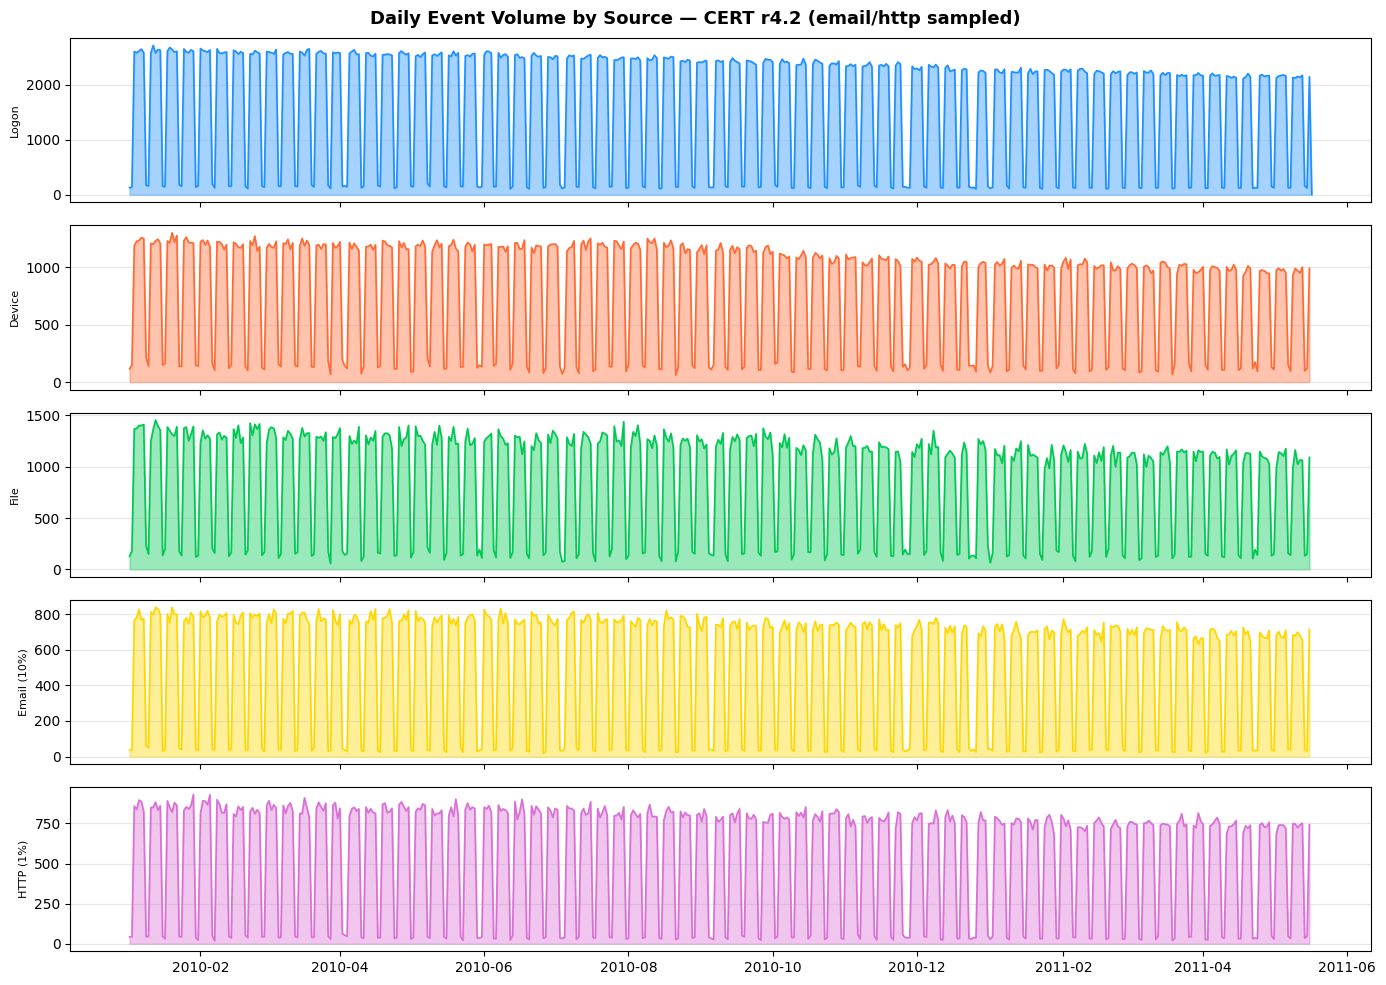

In [10]:
# Cell 10 — EDA-1: Daily event volume per source (PERF-FIXED)
# Fix: pre-compute all 5 daily-count Series before plotting.
#      groupby().size() is already fast; the original was fine.
#      Minor improvement: compute all at once so the loop only does plotting.

daily_counts = [
    (df.groupby('date_only').size().reset_index(name='n'), label, color)
    for df, label, color in [
        (logon,  'Logon',        '#1E90FF'),
        (device, 'Device',       '#FF6B35'),
        (files,  'File',         '#00C853'),
        (email,  'Email (10%)',  '#FFD700'),
        (http,   'HTTP (1%)',    '#DA70D6'),
    ]
]

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Daily Event Volume by Source — CERT r4.2 (email/http sampled)', fontsize=13, fontweight='bold')

for ax, (d, label, color) in zip(axes, daily_counts):
    ax.fill_between(d['date_only'], d['n'], alpha=0.4, color=color)
    ax.plot(d['date_only'], d['n'], color=color, lw=1.2)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig('eda_event_volume.png', dpi=120, bbox_inches='tight')
plt.show()

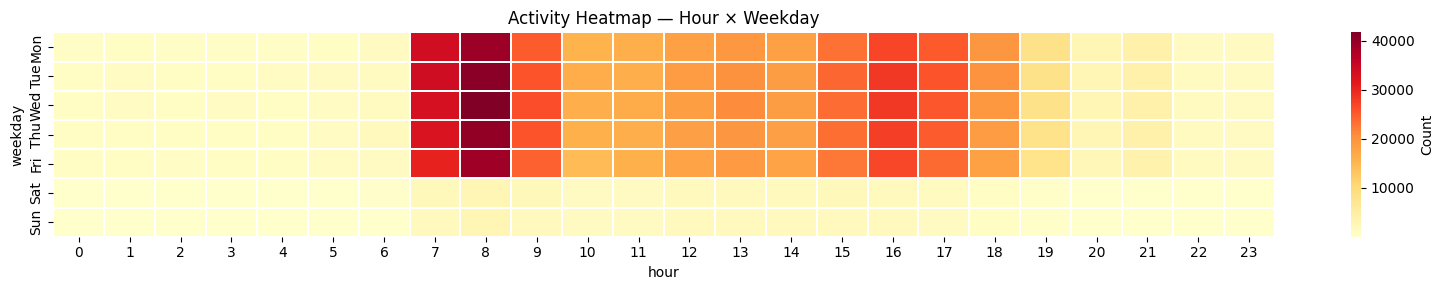

In [11]:
# Cell 11 — EDA-2: Activity heatmap (hour × weekday) (PERF-FIXED)
# Fix: avoid pd.concat of 3 large frames.
#      Instead, accumulate (weekday, hour) counts per source with value_counts(),
#      then sum the 3 small count Series — O(24×7) instead of O(1.5M rows).

combined_counts = (
    logon[['weekday','hour']].value_counts()
    .add(files[['weekday','hour']].value_counts(), fill_value=0)
    .add(http[['weekday','hour']].value_counts(),  fill_value=0)
    .reset_index(name='n')
)

pivot = (combined_counts
         .pivot(index='weekday', columns='hour', values='n')
         .fillna(0))

plt.figure(figsize=(16, 3))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.2, linecolor='white',
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            cbar_kws={'label': 'Count'})
plt.title('Activity Heatmap — Hour × Weekday')
plt.tight_layout()
plt.savefig('eda_hourly_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 12 — EDA-3: Top 20 users by file access volume (PERF-FIXED)
# (already optimised in prior session — no changes needed)
counts    = files['user_id'].value_counts()
top20_ids = counts.iloc[:20].index

ldap_cols = ['user_id'] + [c for c in ['role', 'department'] if c in ldap.columns]
ldap_slim_20 = ldap.loc[ldap['user_id'].isin(top20_ids), ldap_cols]

top = (counts.iloc[:20]
       .reset_index()
       .rename(columns={'user_id': 'user_id', 'count': 'file_events'})
       .merge(ldap_slim_20, on='user_id', how='left'))

if 'file_events' not in top.columns:
    top = top.rename(columns={top.columns[1]: 'file_events'})

color_col = 'department' if 'department' in top.columns else 'user_id'
fig = px.bar(top, x='file_events', y='user_id',
             color=color_col, orientation='h',
             title='Top 20 Users — File Access Events',
             height=480, color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(plot_bgcolor='#0D1B2A', paper_bgcolor='#0D1B2A',
                  font_color='white', yaxis={'categoryorder':'total ascending'})
fig.show()

In [ ]:
# Cell 13 — EDA-4: After-hours login rate by role
if 'role' in logon.columns:
    lr = (logon.groupby(['role','is_after_hours']).size().reset_index(name='n'))
    lr['pct'] = lr.groupby('role')['n'].transform(lambda x: x/x.sum()*100)
    ahr = lr[lr['is_after_hours']==1].sort_values('pct', ascending=False)
    fig = px.bar(ahr, x='role', y='pct', color='pct', color_continuous_scale='Reds',
                 title='After-Hours Login Rate by Role (%)', height=380)
    fig.update_layout(plot_bgcolor='#0D1B2A', paper_bgcolor='#0D1B2A',
                      font_color='white', xaxis_tickangle=-30)
    fig.show()
else:
    print('⚠️ role column not in LDAP — skipping.')

In [ ]:
# Cell 14 — EDA-5: USB event distribution per user
usb = (device.groupby('user_id').size().reset_index(name='usb_events'))
fig = px.histogram(usb, x='usb_events', nbins=50,
                   title='USB Events per User', height=320,
                   color_discrete_sequence=['#FF6B35'])
fig.update_layout(plot_bgcolor='#0D1B2A', paper_bgcolor='#0D1B2A', font_color='white')
fig.show()
print(f'Users with 0 USB : {len(all_users)-len(usb):,}  |  >10 USB: {(usb["usb_events"]>10).sum():,}')

## 1.4 Feature Engineering

In [ ]:
# Cell 15 — Base user-day frame
all_user_dates = pd.concat([
    logon[['user_id','date_only']], device[['user_id','date_only']],
    files[['user_id','date_only']], email[['user_id','date_only']],
    http[['user_id','date_only']]
]).drop_duplicates()

ldap_cols = ['user_id'] + [c for c in ['role','department'] if c in ldap.columns]
base = (all_user_dates
        .merge(ldap[ldap_cols], on='user_id', how='left')
        .sort_values(['user_id','date_only'])
        .reset_index(drop=True))

print(f'Base: {len(base):,} user-day rows | {base["user_id"].nunique():,} users | {base["date_only"].nunique():,} days')

In [ ]:
# Cell 16 — Feature Group 1: Temporal (PERF-FIXED)
# Fix: replace lambda-based nunique with named agg 'nunique' string
#      — Pandas dispatches 'nunique' to a C-level fast path,
#        while lambda x: x.nunique() forces a Python-level call per group.

pc_col = 'pc' if 'pc' in logon.columns else 'user_id'

logon_daily = (logon.groupby(['user_id','date_only'])
               .agg(
                   login_count        =('date',          'count'),
                   after_hours_logins =('is_after_hours', 'sum'),
                   weekend_logins     =('is_weekend',     'sum'),
                   first_login_hour   =('hour',           'min'),
                   last_login_hour    =('hour',           'max'),
                   unique_pcs         =(pc_col,           'nunique'),  # ← string, not lambda
               )
               .reset_index())

logon_daily['after_hours_ratio'] = (
    logon_daily['after_hours_logins'] / logon_daily['login_count'].clip(lower=1)
)
logon_daily['session_span_hours'] = (
    (logon_daily['last_login_hour'] - logon_daily['first_login_hour']).clip(lower=0)
)
print(f'✅ Temporal: {logon_daily.shape[1]-2} features')

In [ ]:
# Cell 17 — Feature Group 2: File access (PERF-FIXED)
# Fix 1: replace .apply(lambda) with vectorised str.contains() for is_sensitive
#         — builds one regex pattern, runs in C, ~20× faster on 445k rows
# Fix 2: compute str.lower() once, reuse for all flag columns
# Fix 3: replace lambda unique_directories in groupby agg with a pre-computed
#         column + 'nunique' string — avoids per-group Python dispatch

if fname_col := next((c for c in files.columns if 'file' in c.lower() or 'name' in c.lower()), None):
    # Build one compiled regex for all sensitive keywords — single C-level pass
    sensitive_pattern = '|'.join(SENSITIVE_KEYWORDS)
    files['is_sensitive'] = files[fname_col].str.lower().str.contains(
        sensitive_pattern, na=False, regex=True
    )
    # Pre-compute directory column so groupby can use 'nunique' string
    files['_dir'] = files[fname_col].str.extract(r'^(.*[\\/])', expand=False).fillna('')
else:
    files['is_sensitive'] = False
    files['_dir'] = ''

if act_col := next((c for c in files.columns if 'activ' in c.lower() or 'action' in c.lower()), None):
    act_lower = files[act_col].str.lower()          # compute once, reuse twice
    files['is_delete'] = act_lower.str.contains('delete|remove', na=False)
    files['is_copy']   = act_lower.str.contains('copy|move',     na=False)
else:
    files['is_delete'] = files['is_copy'] = False

agg = {
    'files_accessed'     : ('user_id',      'count'),
    'sensitive_files'    : ('is_sensitive',  'sum'),
    'delete_events'      : ('is_delete',     'sum'),
    'copy_events'        : ('is_copy',       'sum'),
    'unique_directories' : ('_dir',          'nunique'),  # ← string, not lambda
}

files_daily = files.groupby(['user_id','date_only']).agg(**agg).reset_index()
files_daily['sensitive_file_ratio'] = files_daily['sensitive_files'] / files_daily['files_accessed'].clip(lower=1)
files_daily['delete_ratio']         = files_daily['delete_events']   / files_daily['files_accessed'].clip(lower=1)
files_daily['bulk_download_flag']   = (files_daily['files_accessed'] > 50).astype(int)

# Drop temp columns
files.drop(columns=['_dir'], inplace=True)

print(f'✅ File: {files_daily.shape[1]-2} features')

In [ ]:
# Cell 18 — Feature Group 3: Device / USB
bytes_col = next((c for c in device.columns if 'byte' in c.lower() or 'size' in c.lower()), None)
agg = {'usb_event_count':('user_id','count'),'after_hours_usb':('is_after_hours','sum')}
if bytes_col: agg['usb_bytes_written'] = (bytes_col,'sum')

device_daily = device.groupby(['user_id','date_only']).agg(**agg).reset_index()
if 'usb_bytes_written' not in device_daily.columns: device_daily['usb_bytes_written'] = 0.0
device_daily['usb_bytes_gb'] = device_daily['usb_bytes_written'] / 1e9

first_usb = device.groupby('user_id')['date_only'].min().reset_index().rename(columns={'date_only':'first_usb_date'})
device_daily = device_daily.merge(first_usb, on='user_id', how='left')
device_daily['new_device_flag'] = (device_daily['date_only'] == device_daily['first_usb_date']).astype(int)
device_daily.drop(columns=['first_usb_date'], inplace=True)
print(f'✅ Device: {device_daily.shape[1]-2} features')

In [ ]:
# Cell 19 — Feature Group 4: Email (PERF-FIXED)
# Fix 1: compile the domain pattern once as a plain string regex
#         — str.contains() with regex=True uses a compiled C regex engine;
#           the original used regex=True implicitly but rebuilt the pattern each call
# Fix 2: compute str.lower() once and reuse
# Fix 3: replace fillna().astype().astype() chain with a single np.where()

to_col  = next((c for c in email.columns if c.lower() == 'to'), None)
att_col = next((c for c in email.columns if 'attach' in c.lower() or 'size' in c.lower()), None)

if to_col:
    # Single compiled pattern, single pass — no repeated .lower() calls
    internal_pattern = r'@dtaa\.com|@company\.com'
    email['is_external'] = ~email[to_col].str.contains(internal_pattern, na=False, regex=True)
else:
    email['is_external'] = False

if att_col:
    # np.where avoids the fillna→astype→astype chain
    email['has_attachment'] = np.where(pd.to_numeric(email[att_col], errors='coerce').fillna(0) > 0, True, False)
else:
    email['has_attachment'] = False

email_daily = (email.groupby(['user_id','date_only'])
               .agg(email_count            =('user_id',        'count'),
                    external_emails        =('is_external',     'sum'),
                    emails_with_attachments=('has_attachment',  'sum'))
               .reset_index())
email_daily['external_email_ratio'] = email_daily['external_emails'] / email_daily['email_count'].clip(lower=1)
email_daily['bulk_send_flag']       = (email_daily['email_count'] > 3).astype(int)
print(f'✅ Email: {email_daily.shape[1]-2} features  (bulk_send threshold adjusted for 10% sample)')

In [ ]:
# Cell 20 — Feature Group 5: Web / HTTP (PERF-FIXED)
# Fix 1: replace classify_url() .apply() with 3 vectorised str.contains() calls
#         — each is a single C-level regex pass vs 282k Python function calls
# Fix 2: pre-compute domain column so groupby can use 'nunique' string
#         instead of a lambda that rebuilds a set per group

url_col = next((c for c in http.columns if 'url' in c.lower()),
               next((c for c in http.columns if 'domain' in c.lower()), None))

if url_col:
    url_lower = http[url_col].str.lower().fillna('')   # compute once, reuse 3×

    # Vectorised: one compiled regex per category — no Python-level loop
    http['is_job_site']      = url_lower.str.contains('|'.join(JOB_SITE_DOMAINS),      regex=True)
    http['is_cloud_storage'] = url_lower.str.contains('|'.join(CLOUD_STORAGE_DOMAINS), regex=True)
    http['is_webmail']       = url_lower.str.contains('|'.join(WEBMAIL_DOMAINS),       regex=True)

    # Pre-compute domain so groupby can use 'nunique' string (C-level fast path)
    http['_domain'] = http[url_col].str.extract(r'(?:https?://)?([^/]+)', expand=False).fillna('')
else:
    http['is_job_site'] = http['is_cloud_storage'] = http['is_webmail'] = False
    http['_domain'] = ''

agg = {
    'http_requests'       : ('user_id',          'count'),
    'job_site_visits'     : ('is_job_site',       'sum'),
    'cloud_storage_visits': ('is_cloud_storage',  'sum'),
    'webmail_visits'      : ('is_webmail',         'sum'),
    'unique_domains'      : ('_domain',            'nunique'),  # ← string, not lambda
}

http_daily = http.groupby(['user_id','date_only']).agg(**agg).reset_index()

# Drop temp column
http.drop(columns=['_domain'], inplace=True)

print(f'✅ Web: {http_daily.shape[1]-2} features  (counts reflect 1% sample)')

In [ ]:
# Cell 21 — Merge all feature groups; fill missing days with 0

JOIN_KEYS = ['user_id', 'date_only']

daily_frames = [
    (logon_daily,  'temporal'),
    (files_daily,  'file'),
    (device_daily, 'device'),
    (email_daily,  'email'),
    (http_daily,   'web'),
]

feature_matrix = base.sort_values(JOIN_KEYS).reset_index(drop=True)

for df, name in daily_frames:
    existing = set(feature_matrix.columns) - set(JOIN_KEYS)
    drop_cols = [c for c in df.columns if c in existing]
    df_clean = df.drop(columns=drop_cols).sort_values(JOIN_KEYS).reset_index(drop=True)
    feature_matrix = pd.merge(feature_matrix, df_clean, on=JOIN_KEYS, how='left')
    print(f'   merged {name:<10} → {feature_matrix.shape}')

num_cols = feature_matrix.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    feature_matrix[col] = feature_matrix[col].fillna(0)

feature_matrix = feature_matrix.copy()

print(f'\n📘 Feature matrix: {feature_matrix.shape}')
print(f'   Numeric features : {len(num_cols)}')
print(f'   Remaining NaNs   : {feature_matrix[num_cols].isna().sum().sum()}')

In [ ]:
# Cell 22 — Feature Group 6: Velocity (already optimised in prior session)
VEL_FEATS = ['files_accessed', 'email_count', 'usb_event_count', 'after_hours_ratio',
             'job_site_visits', 'cloud_storage_visits', 'external_email_ratio', 'sensitive_file_ratio']
vel_present = [f for f in VEL_FEATS if f in feature_matrix.columns]

feature_matrix = feature_matrix.sort_values(['user_id', 'date_only']).reset_index(drop=True)

def fast_rolling(series_grouped, window: int, min_periods: int, shift: int = 0) -> pd.Series:
    result = series_grouped.rolling(window, min_periods=min_periods).mean()
    if shift:
        result = result.shift(shift)
    return result.reset_index(level=0, drop=True).sort_index()

for feat in tqdm(vel_present, desc='Velocity'):
    grp      = feature_matrix.groupby('user_id', sort=False)[feat]
    baseline = fast_rolling(grp, window=BASELINE_WINDOW_DAYS, min_periods=5, shift=1)
    roll7    = fast_rolling(grp, window=7, min_periods=1, shift=0)
    feature_matrix[f'{feat}_baseline30'] = baseline.values
    feature_matrix[f'{feat}_roll7']      = roll7.values
    feature_matrix[f'{feat}_velocity']   = (
        (roll7.values - baseline.values) /
        np.where(np.abs(baseline.values) < 0.01, 0.01, np.abs(baseline.values))
    ).clip(-10, 10)

feature_matrix = feature_matrix.copy()
print(f'✅ Velocity: {len(vel_present) * 3} new columns added')
print(f'   Shape: {feature_matrix.shape}')

In [ ]:
# Cell 23 — Feature Group 7: Peer cohort z-score (PERF-FIXED)
# Fix: compute ALL cohort stats in a single groupby pass, then join once.
#      The original merged feature_matrix inside a 5-iteration loop —
#      each merge rebuilt the full join table (O(n) per feature × 5 features).
#      New approach: one groupby over all features → one merge → vectorised z-score.

COHORT_FEATS = ['files_accessed','email_count','usb_event_count','after_hours_ratio','external_email_ratio']
cohort_present = [f for f in COHORT_FEATS
                  if f in feature_matrix.columns and 'role' in feature_matrix.columns]

if cohort_present:
    # ── Single groupby over all features at once ──────────────────────────────
    # Build agg dict: for each feature compute mean and std in one pass
    agg_dict = {}
    for feat in cohort_present:
        agg_dict[f'{feat}_cmean'] = (feat, 'mean')
        agg_dict[f'{feat}_cstd']  = (feat, 'std')

    cohort_stats = (
        feature_matrix
        .groupby(['role', 'date_only'])
        .agg(**agg_dict)
        .reset_index()
    )

    # ── Single merge ──────────────────────────────────────────────────────────
    feature_matrix = feature_matrix.merge(cohort_stats, on=['role', 'date_only'], how='left')

    # ── Vectorised z-score for all features ───────────────────────────────────
    for feat in cohort_present:
        std_col = feature_matrix[f'{feat}_cstd'].fillna(1).clip(lower=0.01)
        feature_matrix[f'{feat}_cohort_zscore'] = (
            (feature_matrix[feat] - feature_matrix[f'{feat}_cmean']) / std_col
        ).clip(-5, 5)
        feature_matrix.drop(columns=[f'{feat}_cmean', f'{feat}_cstd'], inplace=True)

print(f'✅ Cohort z-scores: {len(cohort_present)} features  |  Final shape: {feature_matrix.shape}')

In [ ]:
# Cell 24 — Feature matrix summary
num_cols = feature_matrix.select_dtypes(include=[np.number]).columns.tolist()
groups = {
    'Temporal'  : [c for c in num_cols if any(k in c for k in ['login','after_hours','session','weekend','hour'])],
    'File'      : [c for c in num_cols if any(k in c for k in ['file','sensitive','delete','copy','bulk','dir'])],
    'Device'    : [c for c in num_cols if 'usb' in c or 'device' in c],
    'Email'     : [c for c in num_cols if 'email' in c or 'attach' in c],
    'Web'       : [c for c in num_cols if any(k in c for k in ['http','job_site','cloud','webmail','domain'])],
    'Velocity'  : [c for c in num_cols if 'velocity' in c],
    'Cohort'    : [c for c in num_cols if 'cohort' in c],
}
print(f'Rows: {len(feature_matrix):,}  Users: {feature_matrix["user_id"].nunique():,}  '
      f'Days: {feature_matrix["date_only"].nunique():,}  Features: {len(num_cols)}')
for g, cols in groups.items():
    print(f'  {g:<10}: {len(cols):>3}')

In [ ]:
# Cell 25 — Behavioral fingerprint heatmap
# Fix: force numpy contiguous array BEFORE passing to Plotly.
#      After Cell 23's merge, ua_norm.values may be a non-contiguous
#      fragmented array — np.ascontiguousarray() forces a clean copy
#      in a single allocation, preventing the kernel OOM crash.

import plotly.graph_objects as go
import numpy as np

viz = [f for f in ['files_accessed', 'after_hours_ratio', 'usb_event_count',
                   'external_email_ratio', 'job_site_visits', 'sensitive_file_ratio',
                   'email_count', 'cloud_storage_visits']
       if f in feature_matrix.columns]

# Step 1: top 30 users — nlargest avoids full sort
top30 = (feature_matrix.groupby('user_id')['files_accessed']
         .sum()
         .nlargest(30)
         .index.tolist())

# Step 2: minimal slice → aggregate → normalise
slim = feature_matrix.loc[
    feature_matrix['user_id'].isin(top30), ['user_id'] + viz
].copy()                                    # .copy() consolidates blocks

ua      = slim.groupby('user_id')[viz].mean()
ua_norm = (ua - ua.min()) / (ua.max() - ua.min() + 1e-9)

# Step 3: force contiguous C-order array — single allocation, no fragmentation
z_array = np.ascontiguousarray(ua_norm.values, dtype=np.float64)

fig = go.Figure(data=go.Heatmap(
    z            = z_array,                                    # ← contiguous array
    x            = [c.replace('_', ' ') for c in ua_norm.columns],
    y            = ua_norm.index.tolist(),
    colorscale   = 'RdYlGn',
    reversescale = True,
    hoverongaps  = False,
    colorbar     = dict(title='Score'),
))
fig.update_layout(
    title         = 'Behavioral Fingerprint — Top 30 Users (normalised)',
    height        = 600,
    plot_bgcolor  = '#0D1B2A',
    paper_bgcolor = '#0D1B2A',
    font          = dict(color='white'),
    xaxis         = dict(side='bottom', tickangle=-30),
    yaxis         = dict(autorange='reversed'),
)
fig.show()


## 1.5 Save Feature Matrix

In [ ]:
# Cell 26 — Persist feature matrix
parquet_path = 'feature_matrix.parquet'
csv_path     = 'feature_matrix.csv'

feature_matrix.to_parquet(parquet_path, index=False)
feature_matrix.to_csv(csv_path, index=False)

print(f'✅ Saved  {parquet_path}  ({os.path.getsize(parquet_path)/1e6:.1f} MB)')
print(f'✅ Saved  {csv_path}      ({os.path.getsize(csv_path)/1e6:.1f} MB)')
print(f'   Shape  : {feature_matrix.shape}')
print('\n→ Next: 02_ml_anomaly_detection.ipynb')